In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
import time
import os
from datetime import datetime, timedelta
from collections import defaultdict, deque

warnings.filterwarnings("ignore")
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/sample_submission.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/test_identity.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_identity.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/test_transaction.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_transaction.csv


In [2]:
df_raw = pd.read_csv("/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_transaction.csv")

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [4]:
numeric_cols_raw = df_raw.select_dtypes(include=["int64", "float64"]).columns
object_cols_raw = df_raw.select_dtypes(include="object").columns

print(f"\nTotal Rows       : {df_raw.shape[0]:,}")
print(f"Total Columns    : {df_raw.shape[1]:,}")
print(f"Numeric Columns  : {len(numeric_cols_raw)}")
print(f"Categorical Cols : {len(object_cols_raw)}")
print("\nData Type Distribution:")
print(df_raw.dtypes.value_counts())
df_raw.describe()


Total Rows       : 590,540
Total Columns    : 394
Numeric Columns  : 380
Categorical Cols : 14

Data Type Distribution:
float64    376
object      14
int64        4
Name: count, dtype: int64


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000



isFraud counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud Rate : 3.4990%
Imbalance  : 1 fraud per 27 legit txn


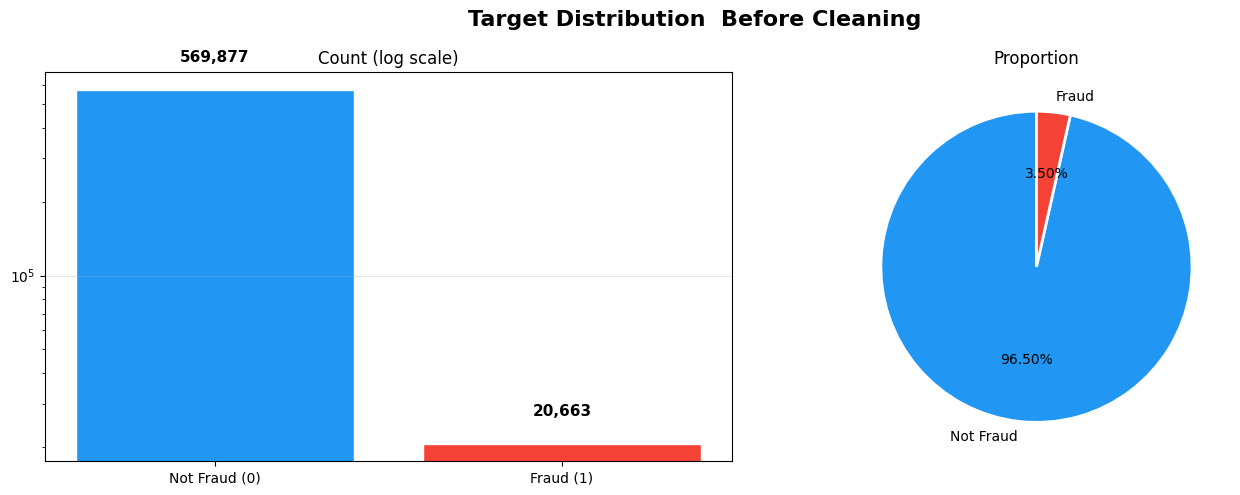

In [5]:
fraud_counts = df_raw["isFraud"].value_counts()
fraud_rate   = df_raw["isFraud"].mean() * 100

print(f"\nisFraud counts:\n{fraud_counts}")
print(f"\nFraud Rate : {fraud_rate:.4f}%")
print(f"Imbalance  : 1 fraud per {int(fraud_counts[0]/fraud_counts[1])} legit txn")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Target Distribution  Before Cleaning", fontsize=16, fontweight="bold")
colors = ["#2196F3", "#F44336"]

bars = axes[0].bar(["Not Fraud (0)", "Fraud (1)"],
                   fraud_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Count (log scale)"); axes[0].set_yscale("log")
for bar, cnt in zip(bars, fraud_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.3,
                 f"{cnt:,}", ha="center", fontsize=11, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

axes[1].pie(fraud_counts.values, labels=["Not Fraud","Fraud"],
            autopct="%1.2f%%", colors=colors, startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Proportion")
plt.tight_layout(); plt.show()

In [6]:
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_ratio = df_raw.isnull().mean().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "count": missing,
    "ratio": missing_ratio
}).query("count > 0")

print(f"Missing Coloumns: {len(missing_df)}")
print(missing_df.head(20))

Missing Coloumns: 374
        count     ratio
dist2  552913  0.936284
D7     551623  0.934099
D13    528588  0.895093
D14    528353  0.894695
D12    525823  0.890410
D6     517353  0.876068
D9     515614  0.873123
D8     515614  0.873123
V153   508595  0.861237
V149   508595  0.861237
V141   508595  0.861237
V146   508595  0.861237
V154   508595  0.861237
V162   508595  0.861237
V142   508595  0.861237
V158   508595  0.861237
V161   508595  0.861237
V157   508595  0.861237
V138   508595  0.861237
V139   508595  0.861237


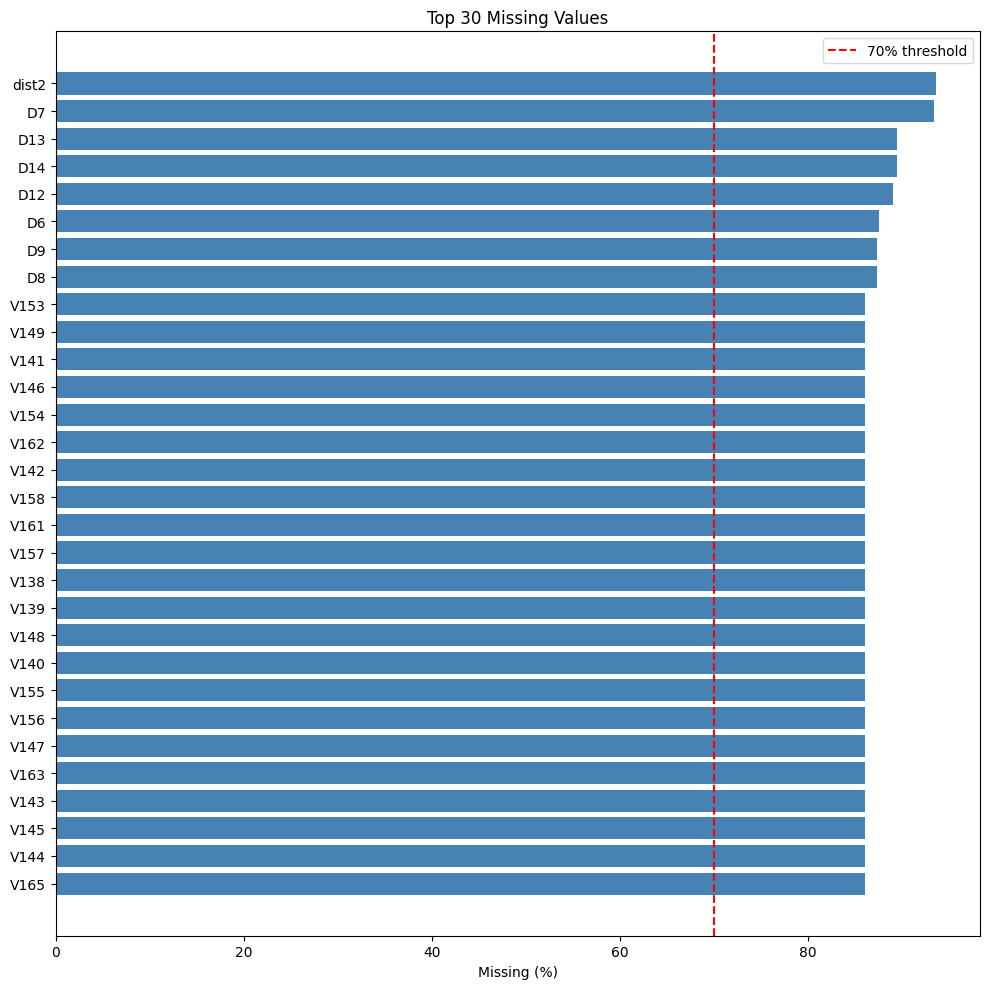

In [7]:
top30 = missing_df.head(30)

plt.figure(figsize=(10, 10))
plt.barh(top30.index[::-1], top30["ratio"][::-1] * 100, color="steelblue")
plt.axvline(x=70, color="red", linestyle="--", label="70% threshold")
plt.xlabel("Missing (%)")
plt.title("Top 30 Missing Values")
plt.legend()
plt.tight_layout()
plt.show()

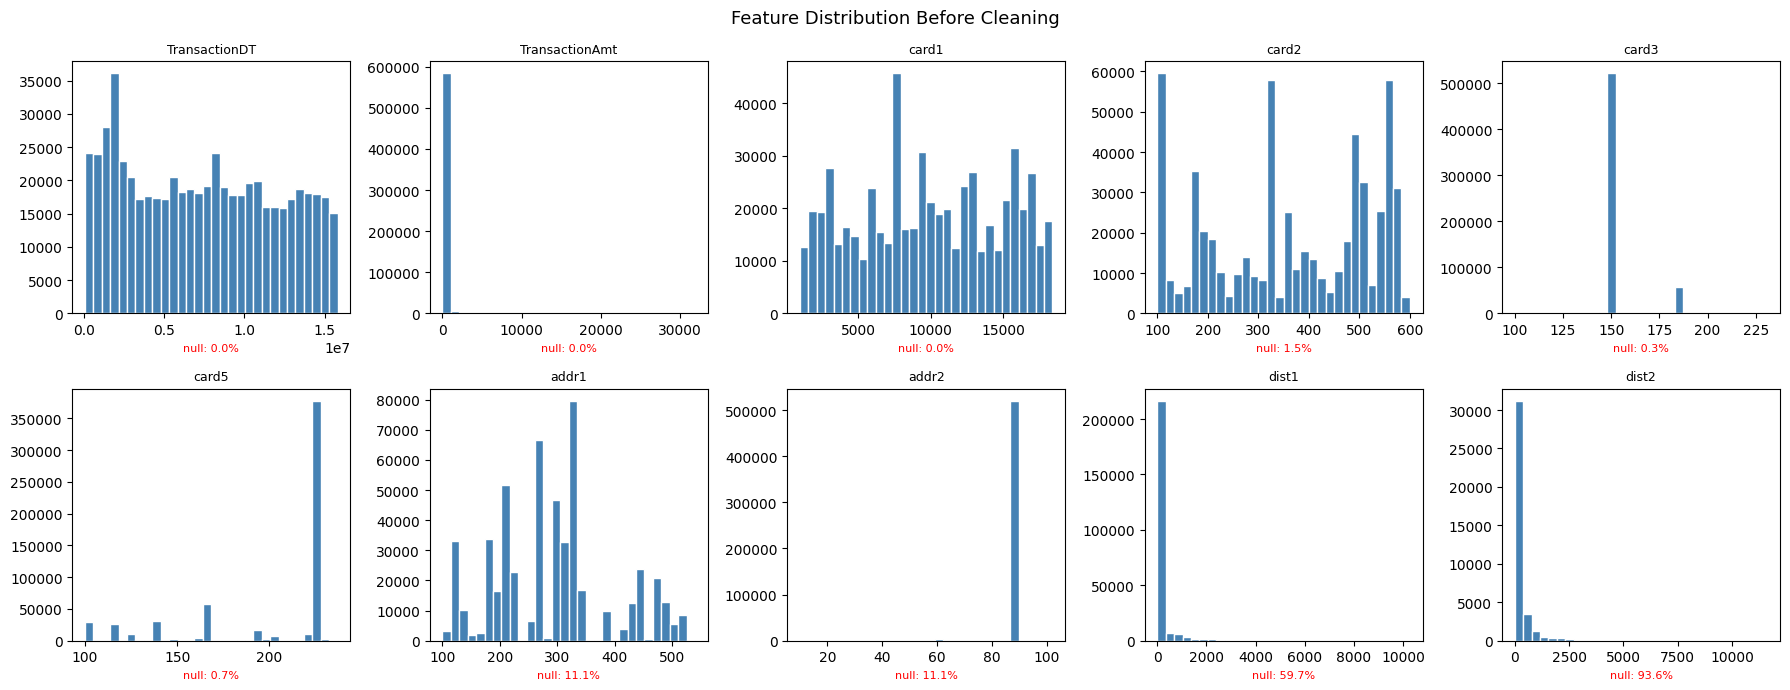

In [8]:
num_sample = [c for c in numeric_cols_raw if c not in ["isFraud", "TransactionID"]][:10]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_sample):
    axes[i].hist(df_raw[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
    null_pct = df_raw[col].isnull().mean() * 100
    axes[i].set_xlabel(f"null: {null_pct:.1f}%", fontsize=8, color="red")

plt.suptitle("Feature Distribution Before Cleaning", fontsize=13)
plt.tight_layout()
plt.show()

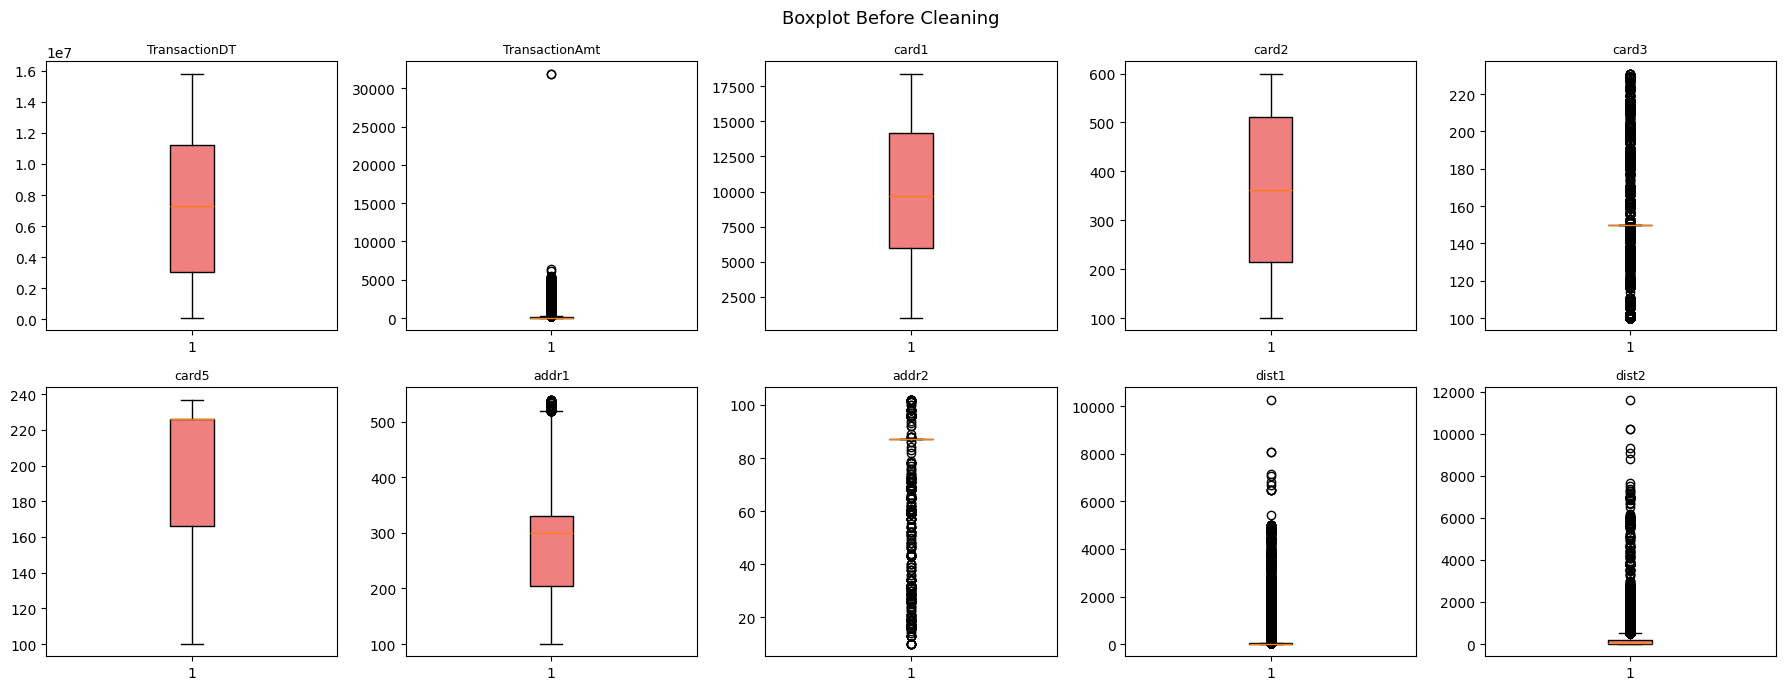

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_sample):
    axes[i].boxplot(df_raw[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="lightcoral"))
    axes[i].set_title(col, fontsize=9)

plt.suptitle("Boxplot Before Cleaning", fontsize=13)
plt.tight_layout()
plt.show()

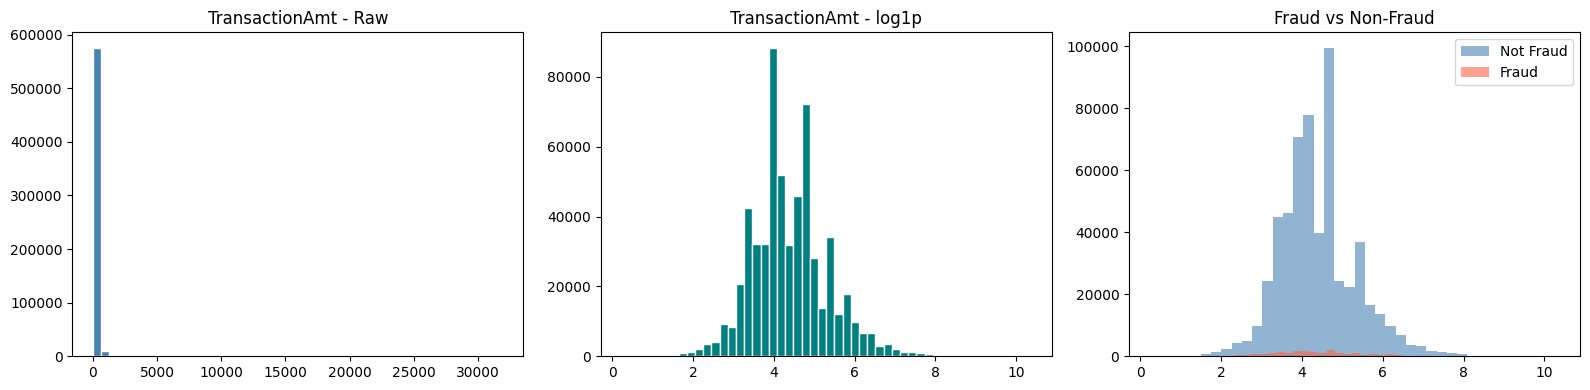

            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_raw["TransactionAmt"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("TransactionAmt - Raw")

axes[1].hist(np.log1p(df_raw["TransactionAmt"].dropna()), bins=50, color="teal", edgecolor="white")
axes[1].set_title("TransactionAmt - log1p")

for lbl, clr, nm in [(0, "steelblue", "Not Fraud"), (1, "tomato", "Fraud")]:
    d = df_raw[df_raw["isFraud"] == lbl]["TransactionAmt"].dropna()
    axes[2].hist(np.log1p(d), bins=40, alpha=0.6, color=clr, label=nm)
axes[2].set_title("Fraud vs Non-Fraud")
axes[2].legend()

plt.tight_layout()
plt.show()

print(df_raw.groupby("isFraud")["TransactionAmt"].describe())

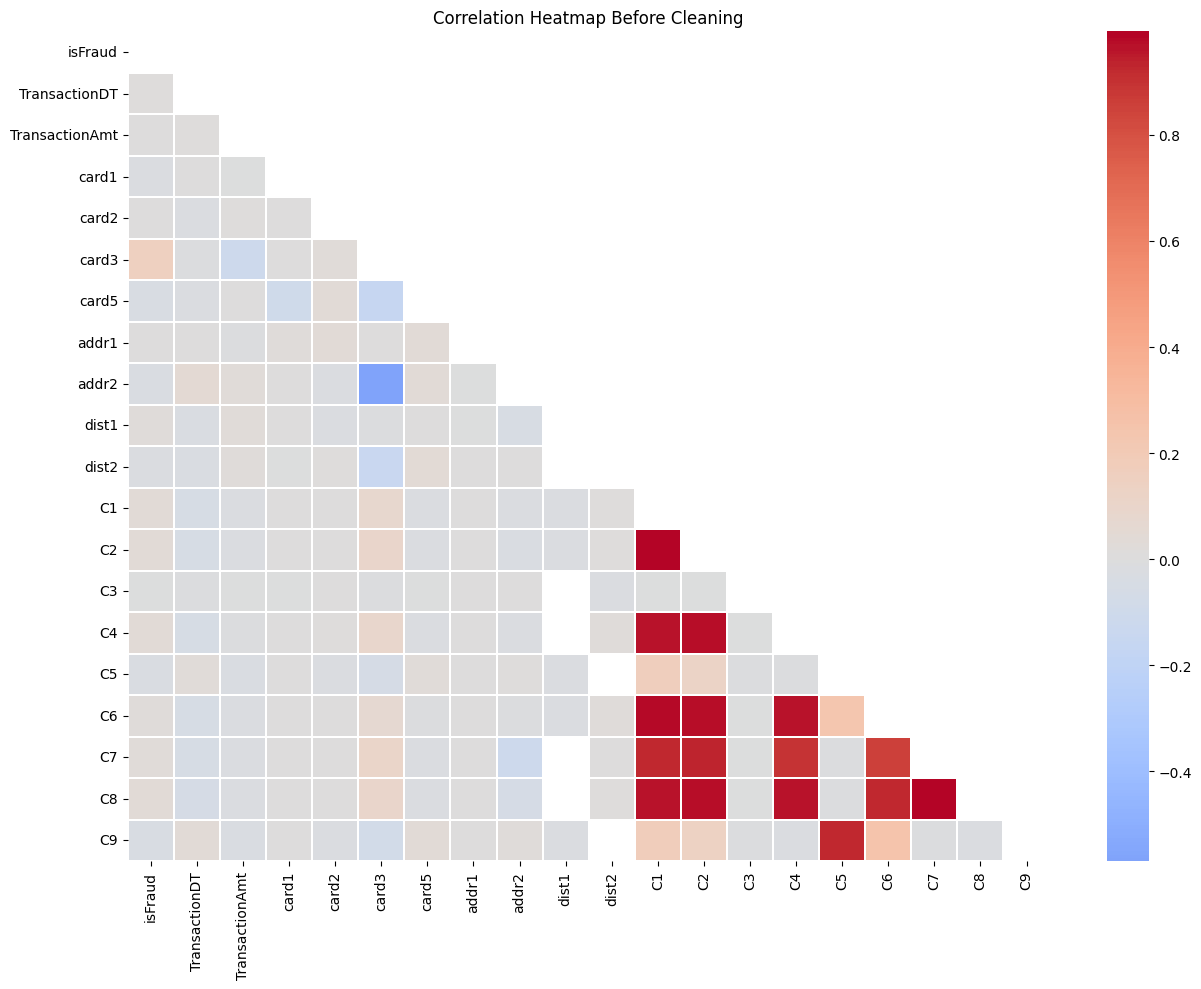

In [11]:
corr_cols = [c for c in numeric_cols_raw if c != "TransactionID"][:20]

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones(len(corr_cols), dtype=bool))
sns.heatmap(df_raw[corr_cols].corr(), mask=mask, cmap="coolwarm",
            center=0, linewidths=0.3)
plt.title("Correlation Heatmap Before Cleaning")
plt.tight_layout()
plt.show()

In [12]:
df = df_raw.copy()

miss_ratio = df.isnull().mean()
cols_to_drop = miss_ratio[miss_ratio > 0.7].index
print(f"dropped columns: {len(cols_to_drop)}")

df = df.drop(columns=cols_to_drop)
print("shape after drop:", df.shape)

dropped columns: 168
shape after drop: (590540, 226)


In [13]:
df = df.drop(columns=["TransactionID"])

In [14]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
object_cols = df.select_dtypes(include="object").columns.tolist()

print("numeric:", len(numeric_cols))
print("categorical:", len(object_cols))

numeric: 212
categorical: 13


In [15]:
for col in numeric_cols:
    if col != "isFraud":
        df[col] = df[col].fillna(df[col].median())

for col in object_cols:
    df[col] = df[col].fillna("missing")

In [16]:
label_encoders = {}
for col in object_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [17]:
df.info()
print("shape:", df.shape)
print("total NaN:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 225 entries, isFraud to V321
dtypes: float64(209), int64(16)
memory usage: 1013.7 MB
shape: (590540, 225)
total NaN: 0


In [18]:
print(f"{'':30} {'before':>10} {'after':>10}")
print(f"{'rows':<30} {df_raw.shape[0]:>10,} {df.shape[0]:>10,}")
print(f"{'columns':<30} {df_raw.shape[1]:>10} {df.shape[1]:>10}")
print(f"{'missing':<30} {df_raw.isnull().sum().sum():>10,} {df.isnull().sum().sum():>10,}")

                                   before      after
rows                              590,540    590,540
columns                               394        225
missing                        95,566,686          0


In [19]:
print(df["isFraud"].value_counts())
print(f"fraud rate: {df['isFraud'].mean()*100:.4f}%")

isFraud
0    569877
1     20663
Name: count, dtype: int64
fraud rate: 3.4990%


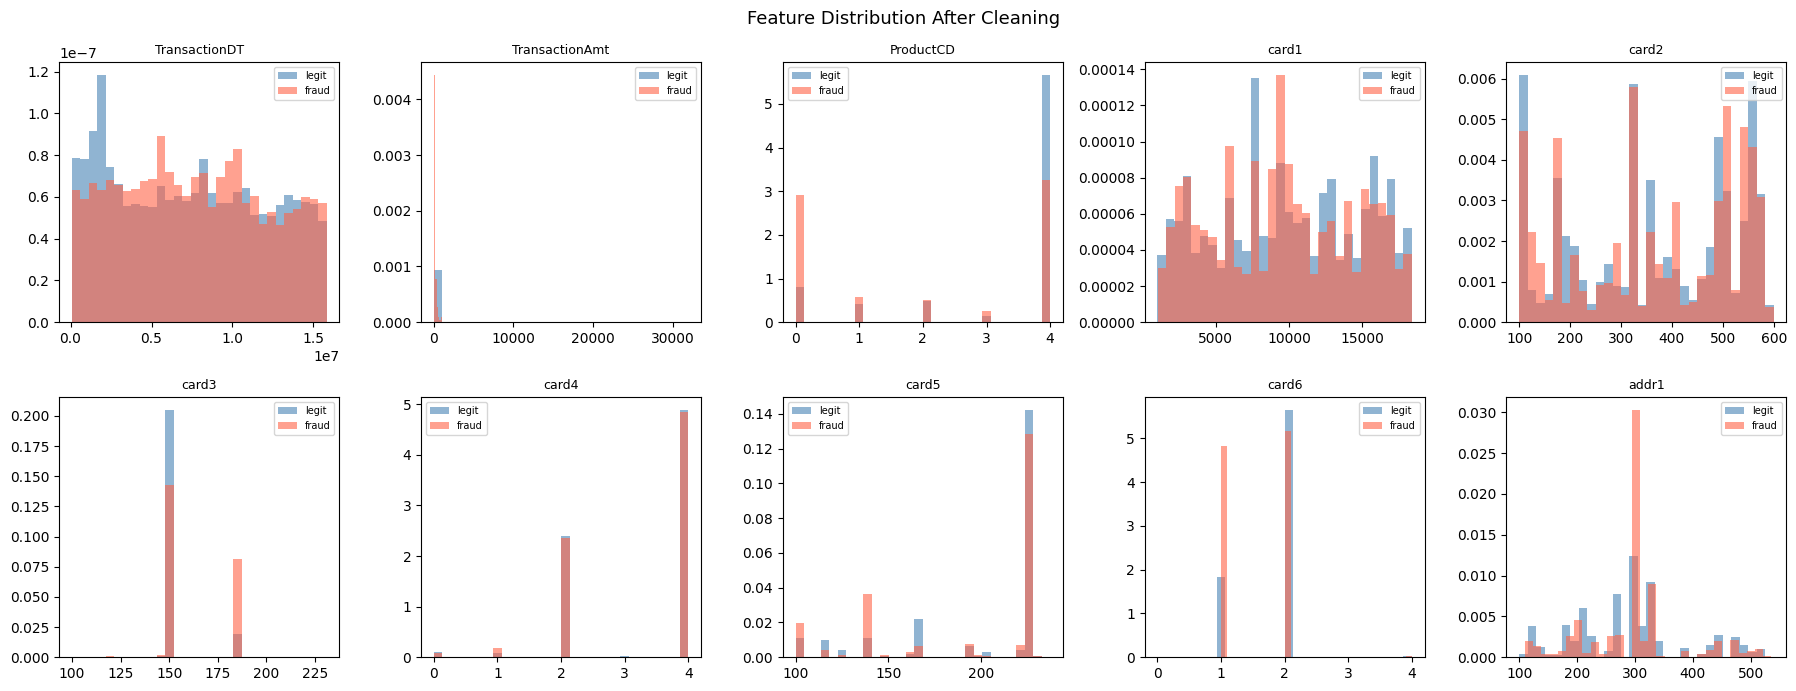

In [20]:
ncs = [c for c in df.columns if c != "isFraud"][:10]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(ncs):
    axes[i].hist(df[df["isFraud"] == 0][col], bins=30, alpha=0.6,
                 color="steelblue", label="legit", density=True)
    axes[i].hist(df[df["isFraud"] == 1][col], bins=30, alpha=0.6,
                 color="tomato", label="fraud", density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle("Feature Distribution After Cleaning", fontsize=13)
plt.tight_layout()
plt.show()

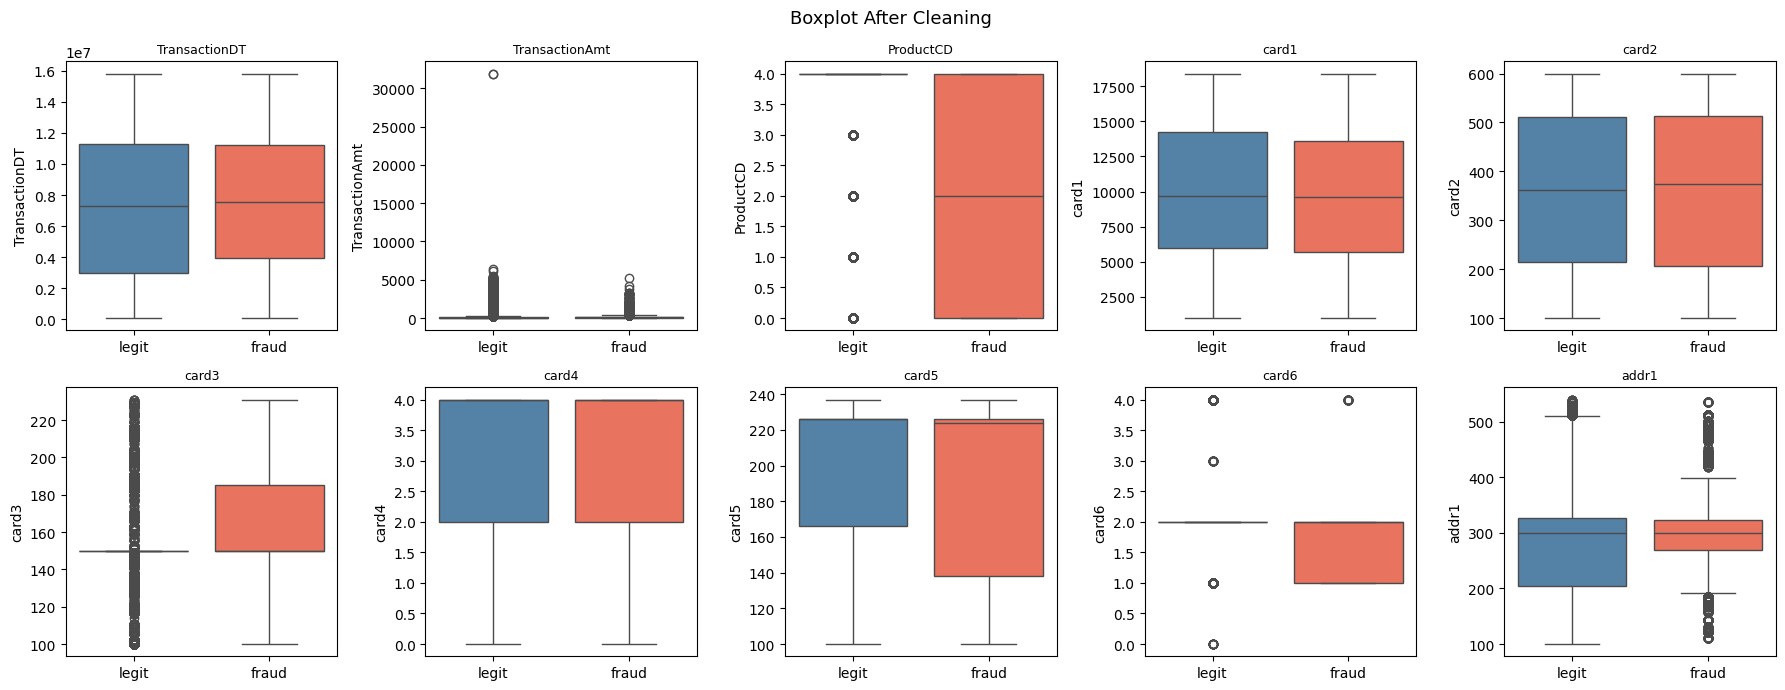

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(ncs):
    tmp = df[[col, "isFraud"]].copy()
    tmp["label"] = tmp["isFraud"].map({0: "legit", 1: "fraud"})
    sns.boxplot(data=tmp, x="label", y=col, ax=axes[i],
                palette={"legit": "steelblue", "fraud": "tomato"})
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

plt.suptitle("Boxplot After Cleaning", fontsize=13)
plt.tight_layout()
plt.show()

V45          0.235436
V86          0.222343
V87          0.221568
V44          0.217870
V52          0.195492
V51          0.182007
V40          0.174672
V79          0.167299
V39          0.166640
V38          0.165903
V43          0.162243
V94          0.161454
V33          0.159394
V17          0.158972
V18          0.158933
V81          0.157356
ProductCD   -0.156556
V34          0.156433
V74          0.156239
V80          0.155256
Name: isFraud, dtype: float64


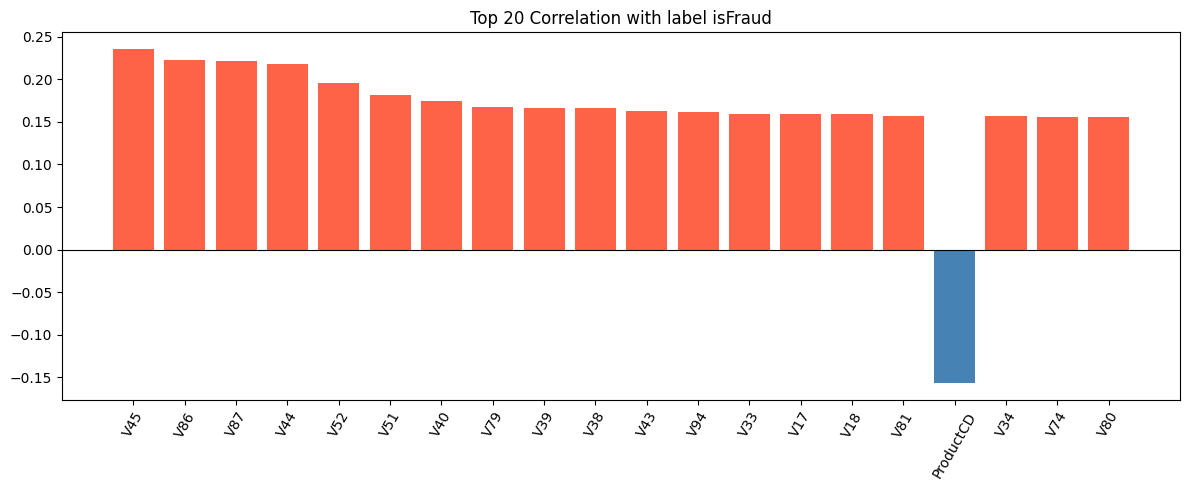

In [22]:
corr_target = df.corr()["isFraud"].drop("isFraud").sort_values(key=abs, ascending=False)
print(corr_target.head(20))

top20 = corr_target.head(20)
plt.figure(figsize=(12, 5))
plt.bar(top20.index, top20.values,
        color=["tomato" if v > 0 else "steelblue" for v in top20.values])
plt.axhline(0, color="black", lw=0.8)
plt.title("Top 20 Correlation with label isFraud")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

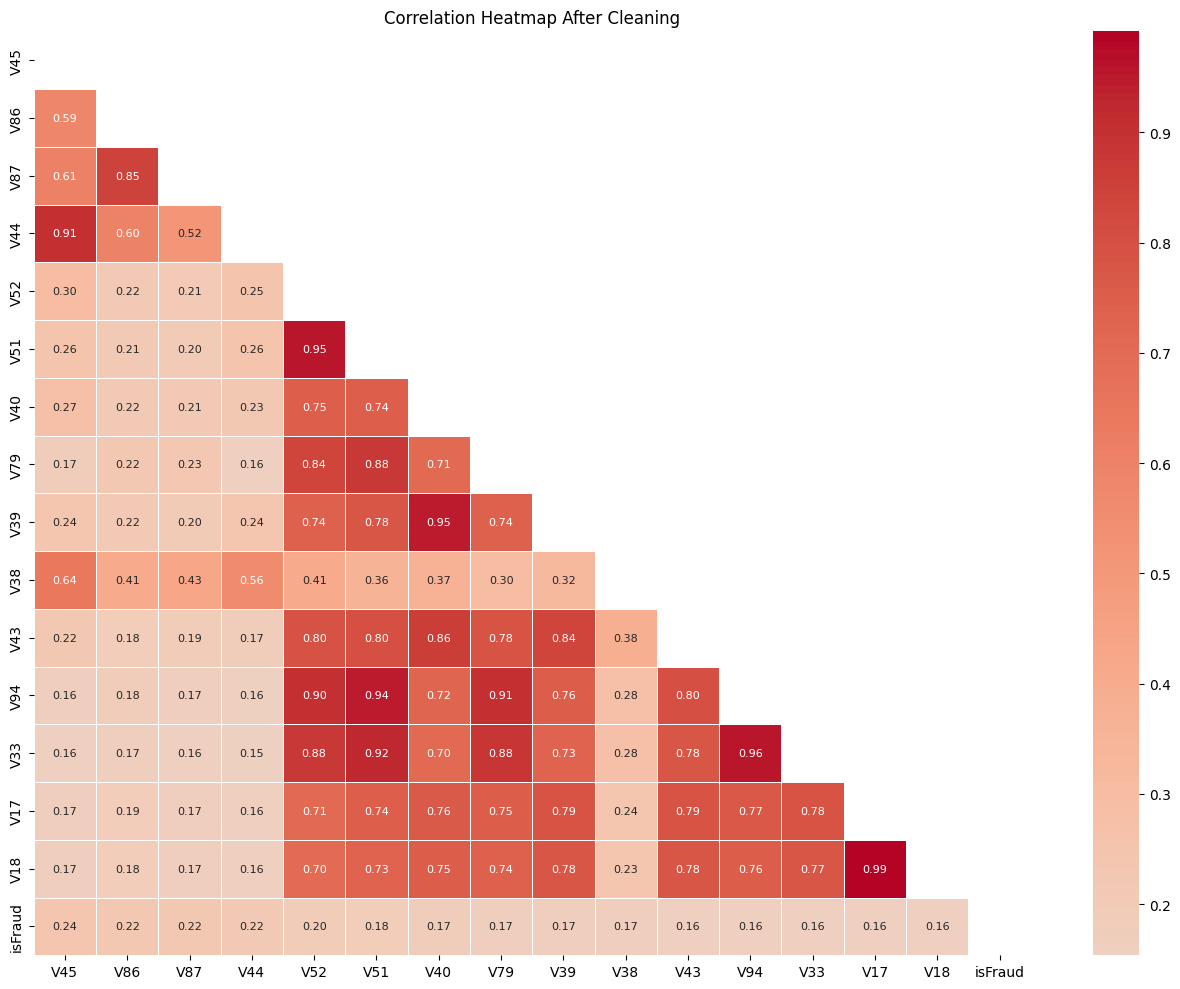

In [23]:
top_feats = corr_target.head(15).index.tolist() + ["isFraud"]

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones(len(top_feats), dtype=bool))
sns.heatmap(df[top_feats].corr(), mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Heatmap After Cleaning")
plt.tight_layout()
plt.show()

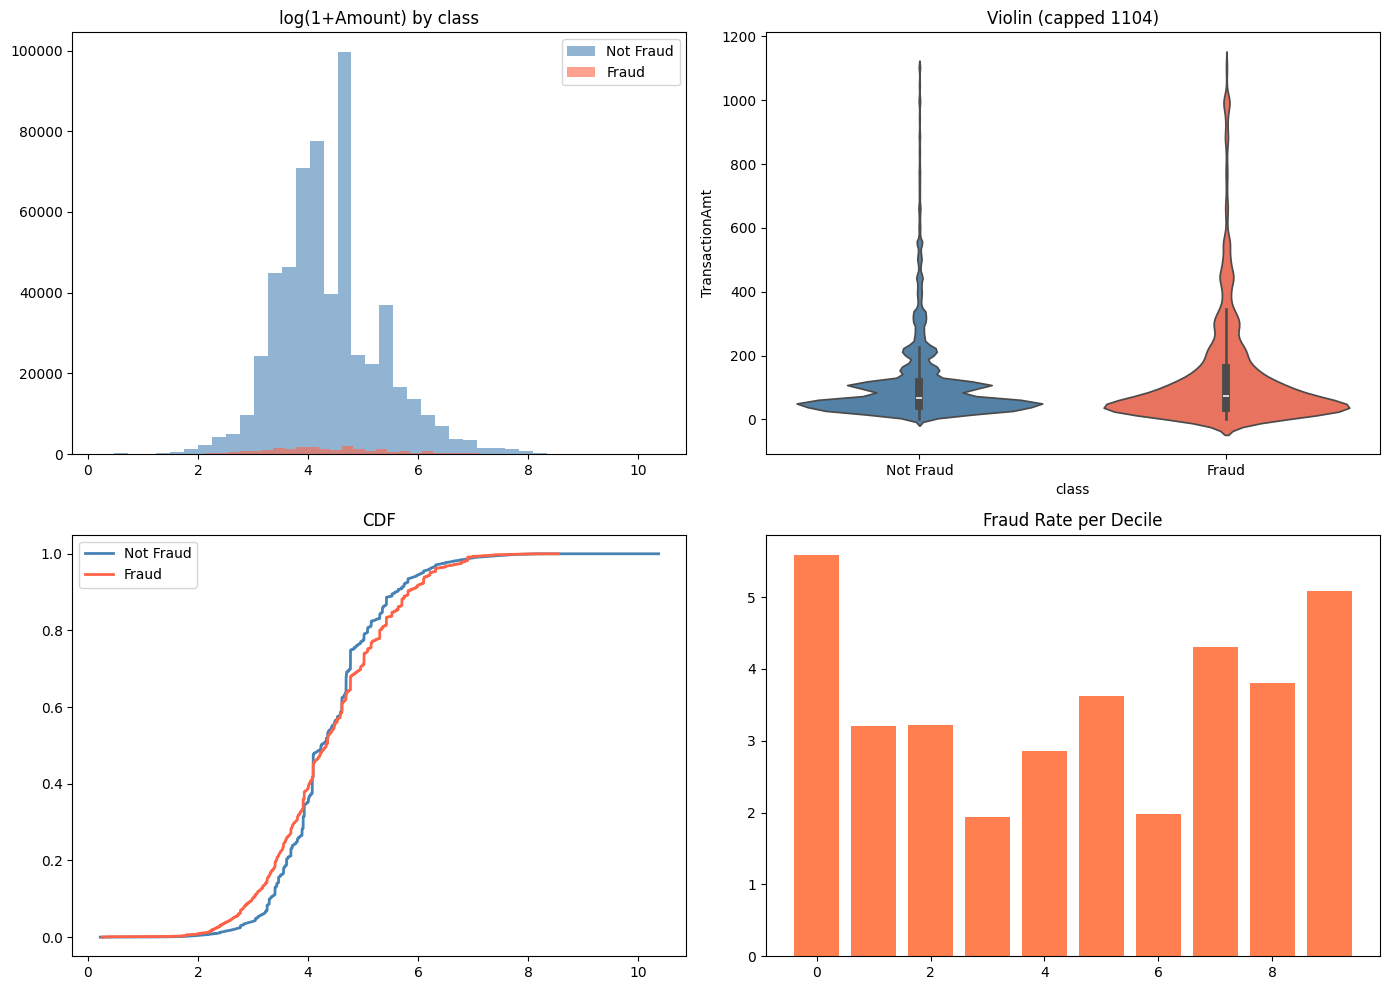

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for lbl, clr, nm in [(0, "steelblue", "Not Fraud"), (1, "tomato", "Fraud")]:
    d = df[df["isFraud"] == lbl]["TransactionAmt"]
    axes[0, 0].hist(np.log1p(d), bins=40, alpha=0.6, color=clr, label=nm)
axes[0, 0].set_title("log(1+Amount) by class")
axes[0, 0].legend()

cap = df["TransactionAmt"].quantile(0.99)
tmp_v = df[df["TransactionAmt"] <= cap].copy()
tmp_v["class"] = tmp_v["isFraud"].map({0: "Not Fraud", 1: "Fraud"})
sns.violinplot(data=tmp_v, x="class", y="TransactionAmt",
               palette={"Not Fraud": "steelblue", "Fraud": "tomato"}, ax=axes[0, 1])
axes[0, 1].set_title(f"Violin (capped {cap:.0f})")

for lbl, clr, nm in [(0, "steelblue", "Not Fraud"), (1, "tomato", "Fraud")]:
    d = np.sort(np.log1p(df[df["isFraud"] == lbl]["TransactionAmt"]))
    axes[1, 0].plot(d, np.arange(1, len(d)+1) / len(d), color=clr, label=nm, lw=2)
axes[1, 0].set_title("CDF")
axes[1, 0].legend()

df["_buck"] = pd.qcut(df["TransactionAmt"], q=10, duplicates="drop", labels=False)
fbuck = df.groupby("_buck")["isFraud"].mean() * 100
axes[1, 1].bar(fbuck.index, fbuck.values, color="coral")
axes[1, 1].set_title("Fraud Rate per Decile")
df.drop(columns=["_buck"], inplace=True)

plt.tight_layout()
plt.show()

TransactionDT    2.131875e+13
card1            2.402147e+07
V307             1.928921e+07
V127             1.795680e+07
V317             1.584042e+07
V133             1.440438e+07
V308             9.131842e+06
V128             9.056862e+06
V318             7.802611e+06
V134             7.685379e+06
V306             5.516983e+06
V126             5.505262e+06
V316             5.152946e+06
V132             5.132512e+06
V320             2.241971e+05
dtype: float64


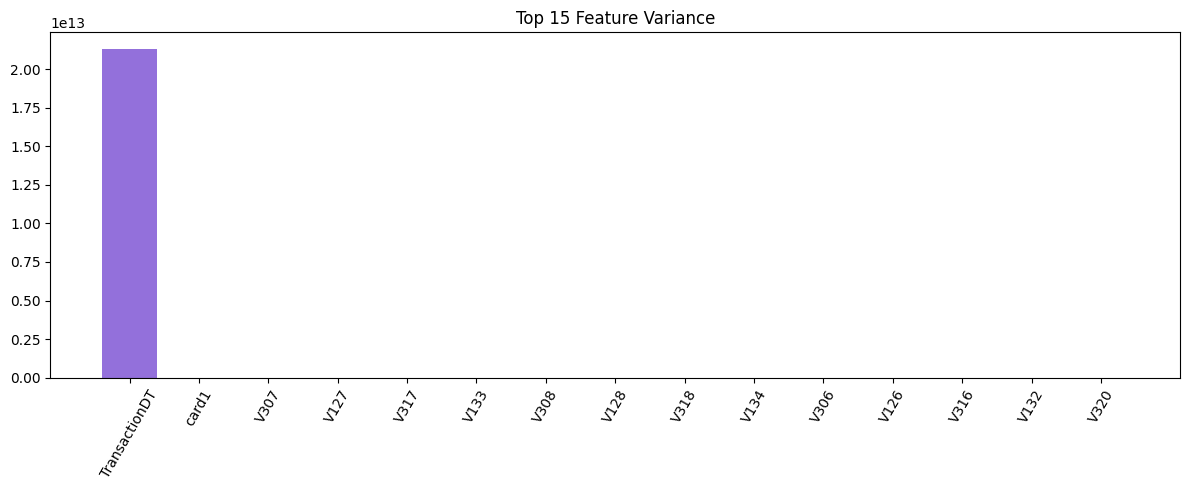

In [25]:
feat_var = df.drop(columns=["isFraud"]).var().sort_values(ascending=False)
print(feat_var.head(15))

plt.figure(figsize=(12, 5))
plt.bar(feat_var.head(15).index, feat_var.head(15).values, color="mediumpurple")
plt.title("Top 15 Feature Variance")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [26]:
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"train: {X_train.shape[0]:,} | fraud: {y_train.sum():,}")
print(f"test : {X_test.shape[0]:,} | fraud: {y_test.sum():,}")

train: 472,432 | fraud: 16,530
test : 118,108 | fraud: 4,133


In [27]:
contamination = float(y_train.mean())
print(f"contamination: {contamination:.5f}")

t0 = time.time()

model = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_sc)
print(f"done ({time.time() - t0:.1f}s)")

contamination: 0.03499
done (6.2s)


In [28]:
y_pred_raw = model.predict(X_test_sc)
y_pred = np.where(y_pred_raw == -1, 1, 0)  # -1 = anomali = fraud

raw_scores = model.score_samples(X_test_sc)
y_score = -raw_scores
y_prob = (y_score - y_score.min()) / (y_score.max() - y_score.min())

print(f"flagged as fraud: {y_pred.sum():,}")
print(f"actual fraud    : {y_test.sum():,}")

flagged as fraud: 4,164
actual fraud    : 4,133


In [29]:
print(classification_report(y_test, y_pred, target_names=["Not Fraud", "Fraud"]))

roc = roc_auc_score(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)

print(f"ROC-AUC   : {roc:.4f}")
print(f"Avg PRC   : {ap:.4f}")
print(f"F1        : {f1:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")

              precision    recall  f1-score   support

   Not Fraud       0.97      0.97      0.97    113975
       Fraud       0.19      0.19      0.19      4133

    accuracy                           0.94    118108
   macro avg       0.58      0.58      0.58    118108
weighted avg       0.94      0.94      0.94    118108

ROC-AUC   : 0.7115
Avg PRC   : 0.1101
F1        : 0.1890
Precision : 0.1883
Recall    : 0.1897


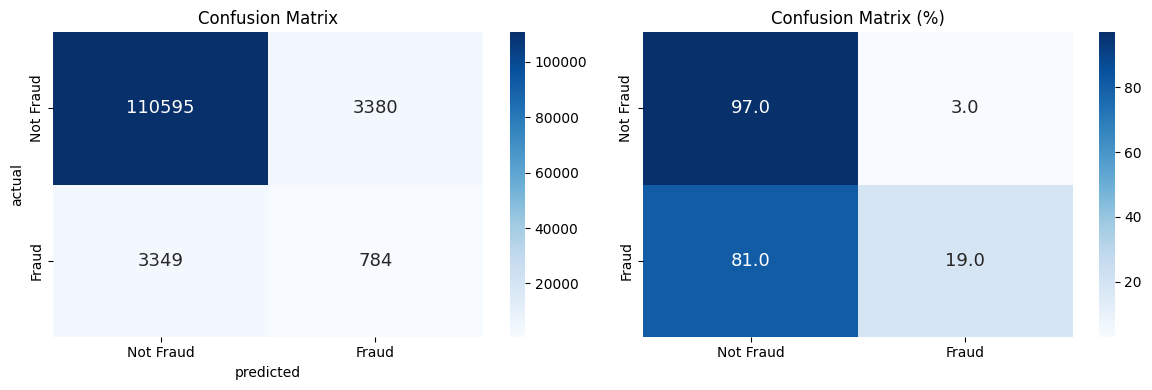

TPR: 18.97%
FPR: 2.97%


In [30]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt="d", ax=axes[0], cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"],
            annot_kws={"size": 13})
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("actual")

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt=".1f", ax=axes[1], cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"],
            annot_kws={"size": 13})
axes[1].set_title("Confusion Matrix (%)")

plt.tight_layout()
plt.show()

print(f"TPR: {tp/(tp+fn)*100:.2f}%")
print(f"FPR: {fp/(fp+tn)*100:.2f}%")

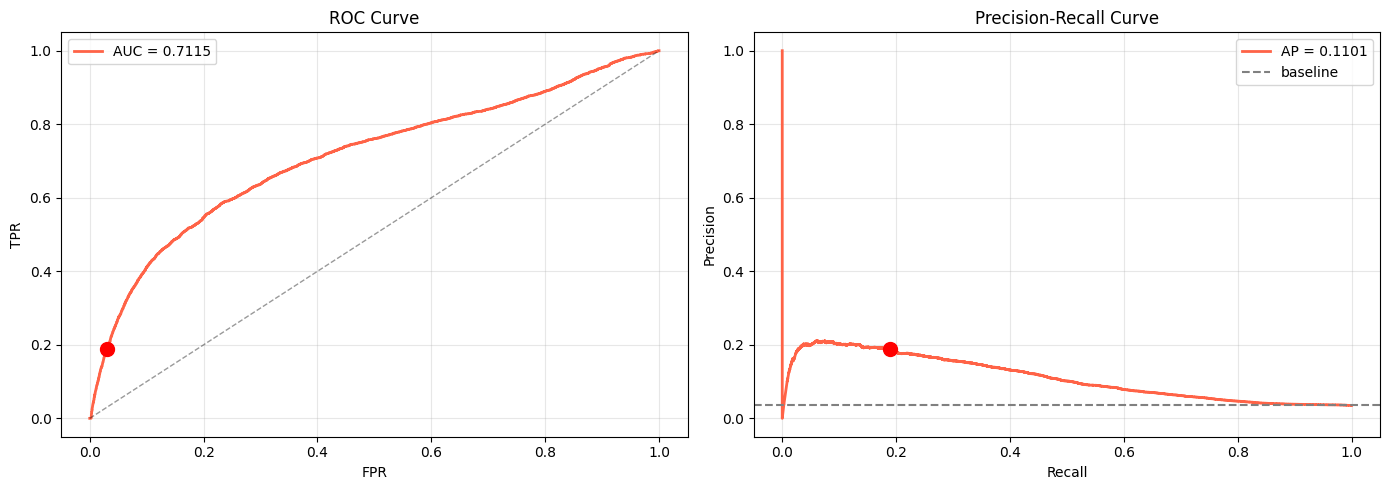

In [31]:
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_prob)
prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr_arr, tpr_arr, color="tomato", lw=2, label=f"AUC = {roc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
axes[0].scatter([fp/(fp+tn)], [tp/(tp+fn)], s=100, color="red", zorder=5)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rec_arr, prec_arr, color="tomato", lw=2, label=f"AP = {ap:.4f}")
axes[1].axhline(y=y_test.mean(), color="grey", ls="--", lw=1.5, label="baseline")
axes[1].scatter([rec], [prec], s=100, color="red", zorder=5)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

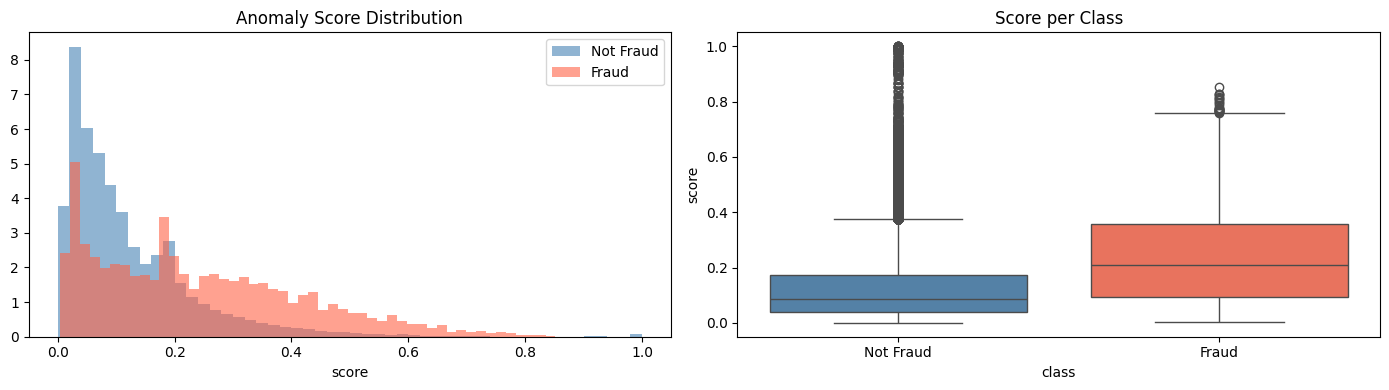

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for lbl, clr, nm in [(0, "steelblue", "Not Fraud"), (1, "tomato", "Fraud")]:
    mask = (y_test == lbl).values
    axes[0].hist(y_prob[mask], bins=50, alpha=0.6, color=clr, label=nm, density=True)
axes[0].set_title("Anomaly Score Distribution")
axes[0].set_xlabel("score")
axes[0].legend()

score_df = pd.DataFrame({"score": y_prob,
                          "class": y_test.map({0: "Not Fraud", 1: "Fraud"}).values})
sns.boxplot(data=score_df, x="class", y="score", ax=axes[1],
            palette={"Not Fraud": "steelblue", "Fraud": "tomato"})
axes[1].set_title("Score per Class")

plt.tight_layout()
plt.show()

 threshold  precision   recall       f1  flagged
      0.10   0.056779 0.734091 0.105406    53435
      0.15   0.072053 0.634648 0.129413    36404
      0.20   0.097358 0.518026 0.163911    21991
      0.25   0.124414 0.430438 0.193034    14299
      0.30   0.146650 0.344786 0.205776     9717
      0.35   0.165775 0.262279 0.203148     6539
      0.40   0.182636 0.196467 0.189299     4446
      0.45   0.194840 0.138882 0.162170     2946
      0.50   0.202133 0.096298 0.130449     1969
      0.55   0.206790 0.064844 0.098729     1296
      0.60   0.201448 0.040406 0.067312      829
      0.65   0.178571 0.024195 0.042617      560
      0.70   0.135266 0.013549 0.024632      414
      0.75   0.082596 0.006775 0.012522      339
      0.80   0.027119 0.001936 0.003613      295
      0.85   0.003610 0.000242 0.000454      277
      0.90   0.000000 0.000000 0.000000      261

best threshold (F1): 0.3


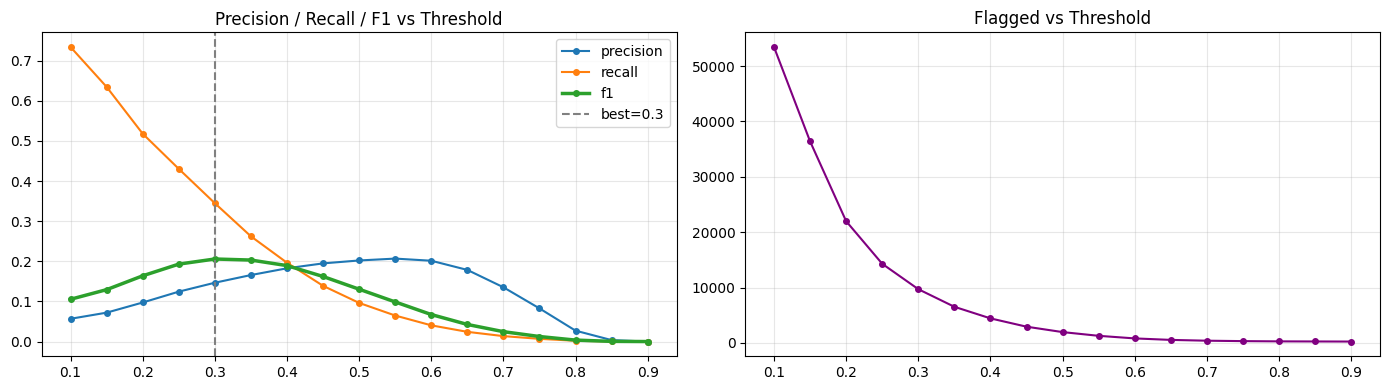

In [33]:
rows = []
for thr in np.arange(0.1, 0.95, 0.05):
    yp = (y_prob >= thr).astype(int)
    rows.append({
        "threshold": round(thr, 2),
        "precision": precision_score(y_test, yp, zero_division=0),
        "recall": recall_score(y_test, yp),
        "f1": f1_score(y_test, yp),
        "flagged": yp.sum()
    })

thr_df = pd.DataFrame(rows)
best_thr = thr_df.loc[thr_df["f1"].idxmax(), "threshold"]
print(thr_df.to_string(index=False))
print(f"\nbest threshold (F1): {best_thr}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(thr_df["threshold"], thr_df["precision"], label="precision", marker="o", ms=4)
axes[0].plot(thr_df["threshold"], thr_df["recall"], label="recall", marker="o", ms=4)
axes[0].plot(thr_df["threshold"], thr_df["f1"], label="f1", marker="o", ms=4, lw=2.5)
axes[0].axvline(best_thr, color="grey", ls="--", label=f"best={best_thr}")
axes[0].set_title("Precision / Recall / F1 vs Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(thr_df["threshold"], thr_df["flagged"], color="purple", marker="o", ms=4)
axes[1].set_title("Flagged vs Threshold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

V72    0.543791
V71    0.542482
V60    0.529711
V59    0.526433
V31    0.526124
V64    0.526040
V63    0.525477
V92    0.516435
V93    0.514660
V32    0.513132
V74    0.508879
V21    0.507643
V17    0.507559
V18    0.504247
V52    0.502493
V51    0.501233
V73    0.497971
V22    0.495133
V85    0.494640
V84    0.492599
dtype: float64


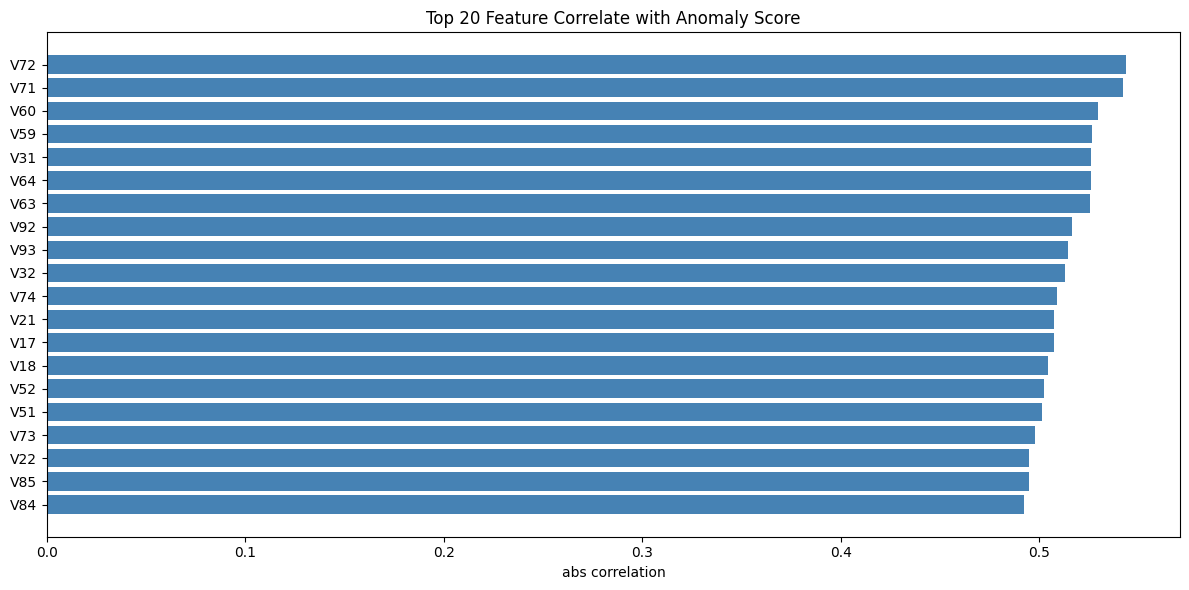

In [34]:
feat_imp = pd.Series(
    [abs(np.corrcoef(X_test_sc[col].values, y_score)[0, 1]) for col in X_test_sc.columns],
    index=X_test_sc.columns
).sort_values(ascending=False).head(20)

print(feat_imp)

plt.figure(figsize=(12, 6))
plt.barh(feat_imp.index[::-1], feat_imp.values[::-1], color="steelblue")
plt.title("Top 20 Feature Correlate with Anomaly Score")
plt.xlabel("abs correlation")
plt.tight_layout()
plt.show()

In [35]:
with open("isolation_forest.pkl", "wb") as f:
    pickle.dump(model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("saved: isolation_forest.pkl, scaler.pkl")

saved: isolation_forest.pkl, scaler.pkl
